# Customer Intelligence Project
### Exploratory Analytics and Predictive Modelling

**Student Name:** Harendra 

**Roll Number:** 2502057

This project analyses the Online Retail II dataset to understand customer purchasing behaviour and build a predictive model to identify customers who are likely to churn.

The analysis consists of two major parts:

A. Exploratory Data Analysis (EDA)

B. Predictive Modelling for Customer Churn

# Part A: Exploratory Data Analysis(EDA)
# A1. Data Loading and Quality Audit

In this section, the dataset is loaded and a complete data quality audit is performed.  
The objective is to understand the structure of the dataset and identify potential data quality issues before performing any analysis.

The audit includes:

- Checking dataset shape
- Inspecting column names and data types
- Identifying missing values
- Detecting duplicate rows
- Identifying negative or zero quantities
- Reviewing potential data inconsistencies

Documenting these issues ensures transparency in the data cleaning process and improves the reliability of subsequent analysis.

## Import Required Libraries

The first step is to import the necessary Python libraries required for data loading, manipulation, and analysis.

In [2]:
import pandas as pd
import numpy as np

## Load the Dataset

The dataset is loaded using the pandas library.  
This dataset contains transactional data from an online retail store, including invoice numbers, product descriptions, quantities, prices, customer IDs, and countries.

In [5]:
df = pd.read_excel("C:/Users/HP/Downloads/online+retail+ii/online_retail_II.xlsx")

# Display first few rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Dataset Shape

The shape of the dataset provides information about the number of rows and columns.  
Rows represent individual transactions, while columns represent variables describing each transaction.

In [6]:
df.shape

(525461, 8)

## Column Names and Data Types

Understanding column data types helps identify whether variables are stored correctly.  
For example:

- Dates should be in datetime format
- Numerical variables should be integers or floats
- Categorical variables should be strings

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


## Summary Statistics

Descriptive statistics provide an overview of numerical variables such as quantity and price.  
This helps identify unusual values such as extremely large quantities or negative values.

In [9]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


## Missing Value Analysis

Missing values can affect analysis and model performance.  
Here we calculate the number of missing values in each column to understand the extent of missing data.

In [10]:
missing_values = df.isnull().sum()
missing_values

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

## Duplicate Row Detection

Duplicate rows occur when the same transaction is recorded more than once.  
Identifying duplicates ensures that revenue calculations and customer analysis are not distorted.

In [11]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(6865)

## Negative and Zero Quantity Analysis

In retail datasets, negative quantities often represent product returns or cancellations.  
Zero quantities may indicate data entry errors or incomplete transactions.

These cases must be identified and handled appropriately before performing revenue analysis.

In [12]:
negative_qty = df[df['Quantity'] < 0]
zero_qty = df[df['Quantity'] == 0]

print("Negative Quantity Rows:", negative_qty.shape[0])
print("Zero Quantity Rows:", zero_qty.shape[0])

Negative Quantity Rows: 12326
Zero Quantity Rows: 0


## Negative or Zero Price Check

Prices should normally be positive values.  
Negative or zero prices may indicate data errors or special transactions that need further inspection.

In [17]:
negative_price = df[df['Price'] < 0]
zero_price = df[df['Price'] == 0]

print("Negative Price Rows:", negative_price.shape[0])
print("Zero Price Rows:", zero_price.shape[0])

Negative Price Rows: 3
Zero Price Rows: 3687


# A2. Revenue and Transaction Analysis

In this section, revenue trends and transaction patterns are analysed to understand the business performance of the retail company.

A new variable called **Revenue** is created by multiplying Quantity and UnitPrice. This allows us to measure the monetary value of each transaction.

The analysis focuses on three main aspects:

- Monthly revenue trends
- Revenue contribution by country
- Revenue contribution by products

These insights help identify peak sales periods, key geographic markets, and top-selling products that drive the company’s revenue.

## Create Revenue Variable

Revenue is calculated by multiplying the number of units purchased (Quantity) by the price per unit (UnitPrice).

This variable represents the total monetary value generated from each transaction.

In [18]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Display first few rows
df[['Quantity','Price','Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


## Convert InvoiceDate to Datetime

To perform time-based analysis, the InvoiceDate column is converted into a datetime format.  
This allows us to extract useful information such as year and month for revenue trend analysis.

In [19]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Year-Month for monthly analysis
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

## Monthly Revenue Analysis

Monthly revenue analysis helps identify trends and seasonal patterns in sales.

By aggregating revenue by month, we can determine:

- Which months generated the highest revenue
- Which months performed poorly
- Whether sales fluctuate seasonally

Understanding these patterns can help the business plan promotions, inventory, and marketing campaigns.

In [20]:
# Calculate monthly revenue
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()

monthly_revenue

,YearMonth,Revenue
0,2009-12,799847.110
1,2010-01,624032.892
2,2010-02,533091.426
3,2010-03,765848.761
4,2010-04,590580.432
5,2010-05,615322.830
6,2010-06,679786.610
7,2010-07,575236.360
8,2010-08,656776.340
9,2010-09,853650.431


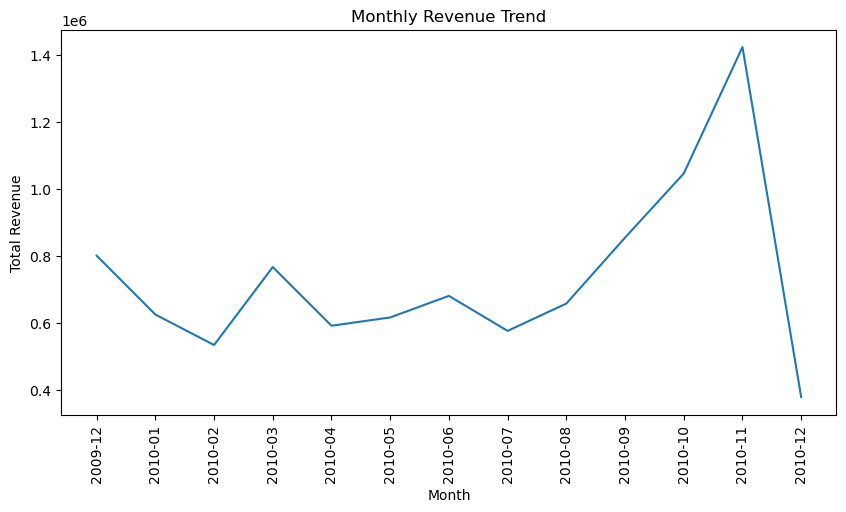

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['YearMonth'].astype(str), monthly_revenue['Revenue'])
plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.show()

## Peak and Lowest Performing Month

To understand performance variations, we identify:

- The **month with the highest revenue**
- The **month with the lowest revenue**

This helps the company understand seasonal demand patterns.

In [22]:
peak_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
lowest_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmin()]

print("Peak Revenue Month:")
print(peak_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Peak Revenue Month:
YearMonth        2010-11
Revenue      1422654.642
Name: 11, dtype: object

Lowest Revenue Month:
YearMonth      2010-12
Revenue      377488.45
Name: 12, dtype: object


## Revenue by Country

This analysis identifies which countries contribute the most revenue to the business.

Understanding geographic revenue distribution helps the company focus marketing efforts and expansion strategies in high-performing regions.

In [23]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

top10_countries = country_revenue.head(10)

top10_countries

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

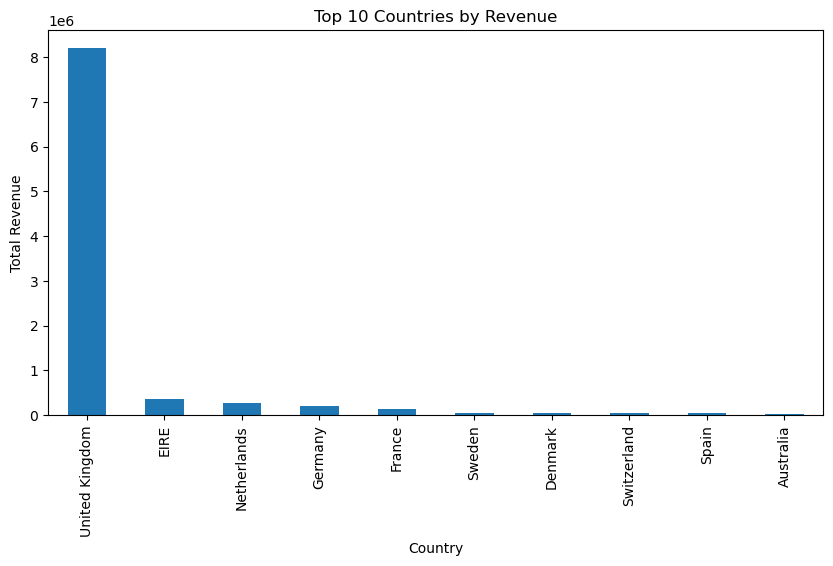

In [24]:
plt.figure(figsize=(10,5))

top10_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.show()

## Top 20 Products by Revenue

This analysis identifies the products that generate the highest revenue.

Understanding product-level performance helps the company:

- Optimize inventory
- Promote best-selling products
- Improve product assortment strategy

In [25]:
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

top20_products = product_revenue.head(20)

top20_products

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
EDWARDIAN PARASOL NATURAL               36422.16
VINTAGE UNION JACK BUNTING              35819.71
STRAWBERRY CERAMIC TRINKET BOX          33834.70
EDWARDIAN PARASOL BLACK                 32350.84
JUMBO  BAG BAROQUE BLACK WHITE          32225.29
JUMBO STORAGE BAG SUKI                  31406.86
CHILLI LIGHTS                           31086.10
CREAM HEART CARD HOLDER                 30998.13
HOME BUILDING BLOCK WORD                30916.72
HOT WATER BOTTLE TEA AND SYMPATHY       30030.06
Name: Re

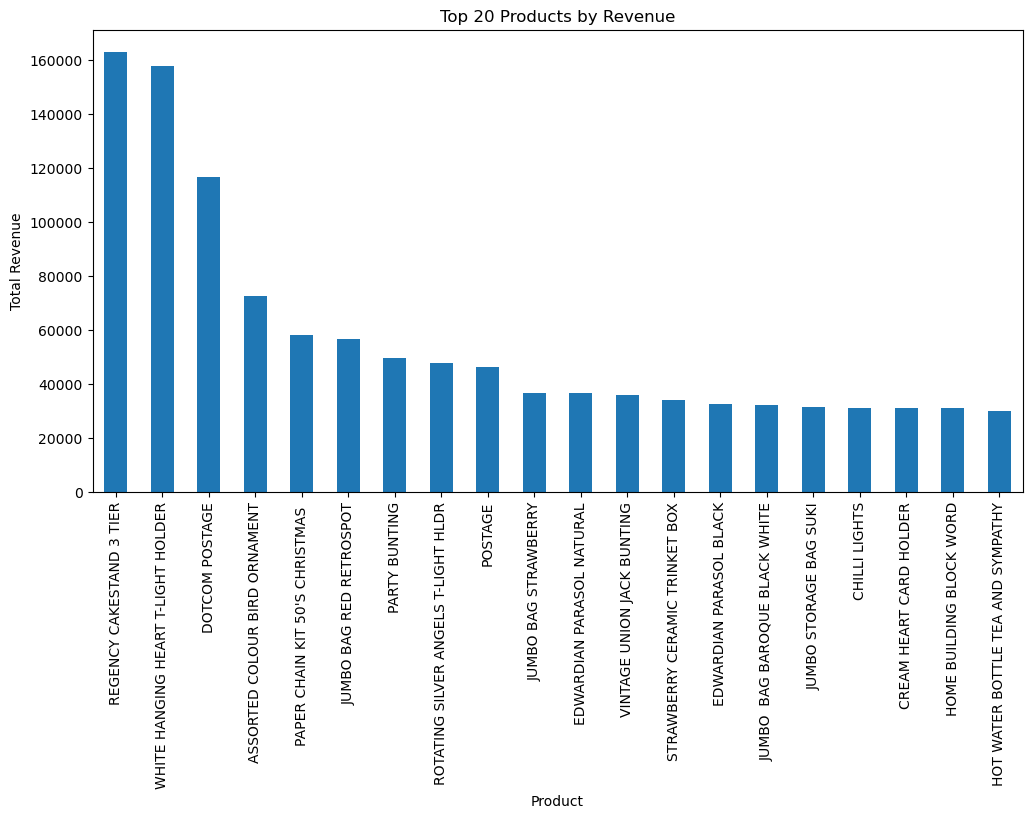

In [26]:
plt.figure(figsize=(12,6))

top20_products.plot(kind='bar')

plt.title("Top 20 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.xticks(rotation=90)

plt.show()

# A3. Customer Behaviour Profiling

In this section, customer purchasing behaviour is analysed by aggregating transaction data at the customer level.

For each customer, we calculate key behavioural metrics:

- Total revenue generated
- Total number of orders placed
- Average order value
- Number of unique products purchased

These metrics help identify high-value customers and understand differences between top customers and average customers.

## Customer-Level Metrics Calculation

To understand customer purchasing behaviour, transaction data is aggregated by **CustomerID**.

The following metrics are calculated:

- **Total Revenue**: Total amount spent by each customer
- **Total Orders**: Number of transactions made by each customer
- **Average Order Value (AOV)**: Average revenue per order
- **Unique Products Purchased**: Number of different products bought by each customer

In [29]:
customer_profile = df.groupby('Customer ID').agg(
    TotalRevenue=('Revenue','sum'),
    TotalOrders=('Invoice','nunique'),
    UniqueProducts=('StockCode','nunique')
)

# Calculate Average Order Value
customer_profile['AverageOrderValue'] = customer_profile['TotalRevenue'] / customer_profile['TotalOrders']

customer_profile.head()

,TotalRevenue,TotalOrders,UniqueProducts,AverageOrderValue
Customer ID,,,,
12346.0,-64.68,15,29,-4.3120
12347.0,1323.32,2,70,661.6600
12348.0,222.16,1,20,222.1600
12349.0,2646.99,4,92,661.7475
12351.0,300.93,1,21,300.9300


## Distribution of Total Revenue per Customer

This visualization shows how total spending is distributed across customers.

It helps identify whether revenue is evenly distributed or concentrated among a small number of customers.

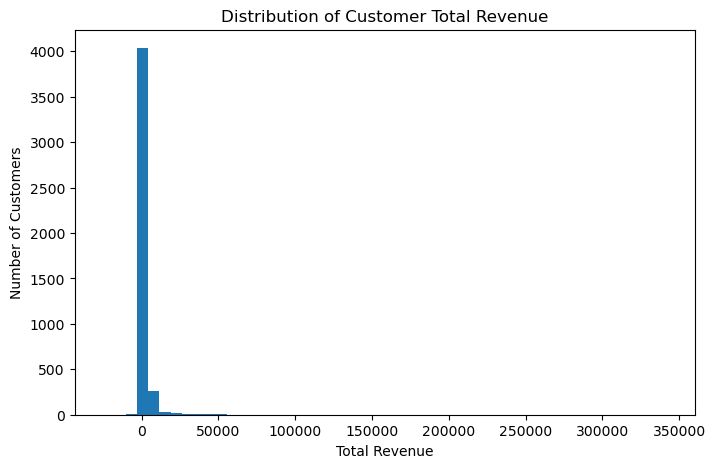

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(customer_profile['TotalRevenue'], bins=50)

plt.title("Distribution of Customer Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")

plt.show()

## Distribution of Total Orders per Customer

This chart shows how frequently customers place orders.

Understanding purchase frequency helps identify loyal customers and occasional buyers.

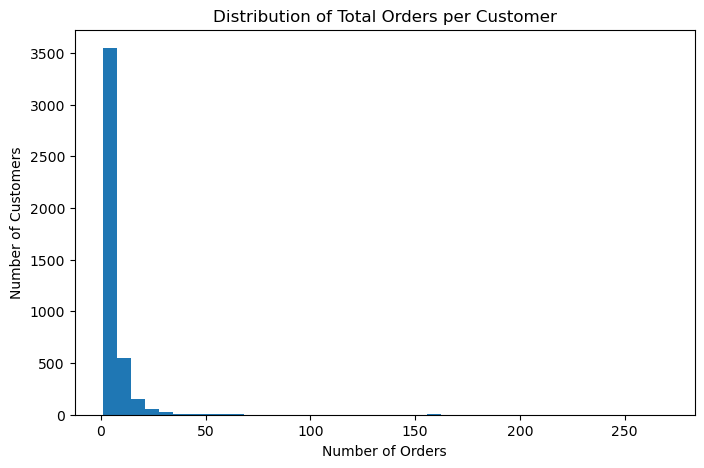

In [31]:
plt.figure(figsize=(8,5))
plt.hist(customer_profile['TotalOrders'], bins=40)

plt.title("Distribution of Total Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

## Distribution of Average Order Value

Average Order Value (AOV) measures how much customers spend per order.

Higher AOV customers are often more valuable and may respond well to premium product offerings.

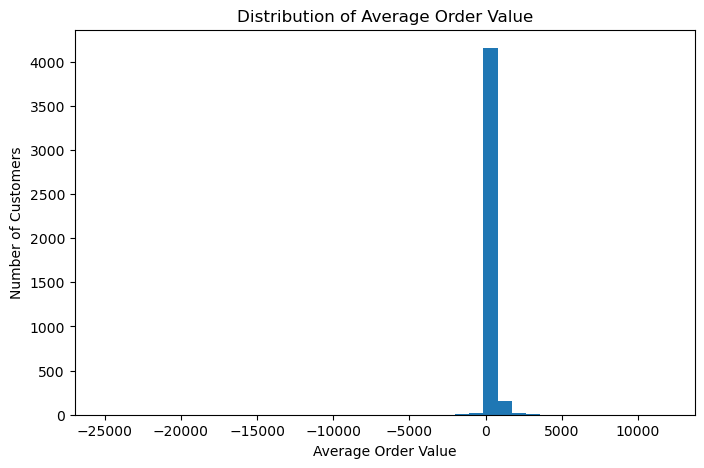

In [32]:
plt.figure(figsize=(8,5))
plt.hist(customer_profile['AverageOrderValue'], bins=40)

plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Customers")

plt.show()

## Distribution of Unique Products Purchased

This metric measures how many different products each customer buys.

Customers purchasing a wider variety of products may indicate stronger engagement with the brand.

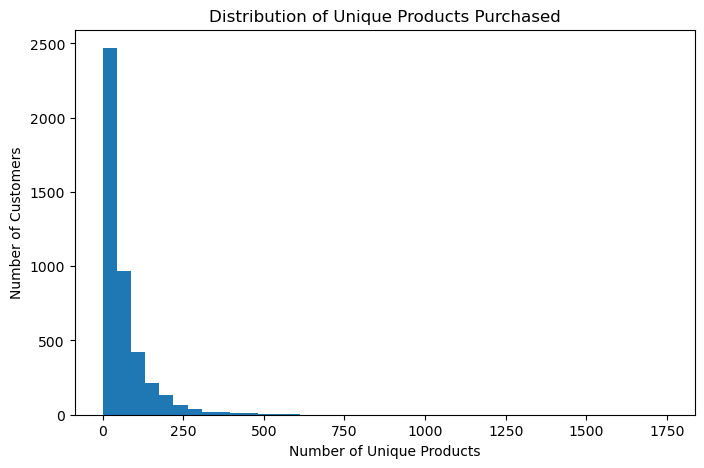

In [33]:
plt.figure(figsize=(8,5))
plt.hist(customer_profile['UniqueProducts'], bins=40)

plt.title("Distribution of Unique Products Purchased")
plt.xlabel("Number of Unique Products")
plt.ylabel("Number of Customers")

plt.show()

## Identifying Top 10% Customers by Revenue

To identify high-value customers, we calculate the top 10% of customers based on total revenue.

These customers typically contribute a significant portion of total company revenue and are critical for business growth.

In [34]:
# Calculate revenue threshold for top 10%
threshold = customer_profile['TotalRevenue'].quantile(0.90)

# Identify top customers
top_customers = customer_profile[customer_profile['TotalRevenue'] >= threshold]

top_customers.head()

,TotalRevenue,TotalOrders,UniqueProducts,AverageOrderValue
Customer ID,,,,
12356.0,3562.25,3,68,1187.416667
12357.0,12079.99,2,165,6039.995000
12380.0,5167.44,10,119,516.744000
12409.0,12033.54,6,125,2005.590000
12415.0,19543.84,7,169,2791.977143


## Comparison: Top Customers vs Other Customers

To understand how high-value customers differ from regular customers, we compare their average behaviour across key metrics.

In [35]:
# Create customer segment label
customer_profile['Segment'] = ['Top 10%' if x >= threshold else 'Others' 
                               for x in customer_profile['TotalRevenue']]

comparison = customer_profile.groupby('Segment').mean()

comparison

,TotalRevenue,TotalOrders,UniqueProducts,AverageOrderValue
Segment,,,,
Others,834.628014,3.629310,48.922414,246.144466
Top 10%,11518.076733,21.123007,188.161731,680.210612


# A4. RFM Segmentation

RFM segmentation is a widely used customer analytics technique that categorizes customers based on their purchasing behaviour.

RFM stands for:

- **Recency (R):** How recently a customer made a purchase
- **Frequency (F):** How often a customer makes purchases
- **Monetary (M):** How much money a customer spends

Customers are scored on each metric from **1 to 5**, where higher scores indicate more valuable customers. These scores are then used to segment customers into groups such as Champions, Loyal, At Risk, Lost, and New customers.

This segmentation helps businesses design targeted marketing and retention strategies.

## Create RFM Table

The first step is to create an RFM table at the customer level.

- **Recency:** Days since the customer's last purchase
- **Frequency:** Number of unique orders placed
- **Monetary:** Total revenue generated by the customer

In [40]:
import datetime as dt

# Reference date (latest date in dataset)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

rfm.rename(columns={
    'InvoiceDate':'Recency',
    'Invoice':'Frequency',
    'Revenue':'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-64.68
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


## Assign RFM Scores (1–5)

Each customer is scored from **1 to 5** for Recency, Frequency, and Monetary using quintiles.

- Lower recency (recent purchases) receives higher scores.
- Higher frequency and spending receive higher scores.

In [41]:
# Recency score (lower recency = better)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency score
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary score
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
Customer ID,,,,,,
12346.0,67,15,-64.68,3,5,1
12347.0,3,2,1323.32,5,2,4
12348.0,74,1,222.16,2,1,1
12349.0,43,4,2646.99,3,3,5
12351.0,11,1,300.93,5,1,2


## Combine RFM Scores

The R, F, and M scores are combined to create an overall RFM score.  
This score helps identify customer segments based on purchasing behaviour.

In [42]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
12346.0,67,15,-64.68,3,5,1,351
12347.0,3,2,1323.32,5,2,4,524
12348.0,74,1,222.16,2,1,1,211
12349.0,43,4,2646.99,3,3,5,335
12351.0,11,1,300.93,5,1,2,512


## Assign Customer Segments

Customers are categorized into segments based on their RFM scores.

Segments include:

- **Champions:** Recent buyers who purchase frequently and spend the most
- **Loyal Customers:** Frequent buyers with strong purchase history
- **New Customers:** Recently acquired customers
- **At Risk:** Customers who previously purchased frequently but have not purchased recently
- **Lost Customers:** Customers who have not purchased for a long time

In [43]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,67,15,-64.68,3,5,1,351,Loyal
12347.0,3,2,1323.32,5,2,4,524,New
12348.0,74,1,222.16,2,1,1,211,Lost
12349.0,43,4,2646.99,3,3,5,335,Loyal
12351.0,11,1,300.93,5,1,2,512,New


## Customer Segment Distribution

This visualization shows the number of customers in each RFM segment.

Understanding the distribution helps the company prioritize marketing and retention strategies.

In [44]:
segment_counts = rfm['Segment'].value_counts()

segment_counts

Segment
Lost         1375
Champions    1096
Loyal         821
At Risk       713
New           378
Name: count, dtype: int64

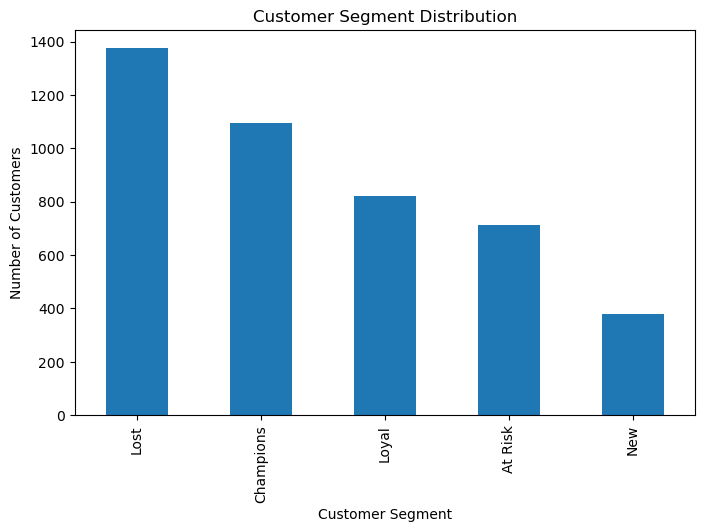

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

# Part B: Predictive Modelling

## B1. Problem Definition and Target Variable

In this section, the objective is to define the prediction problem and create the target variable for the machine learning model.

The business problem is to identify customers who are likely to stop purchasing from the company. This problem is known as **customer churn prediction**.

For this project, a customer is considered **churned** if they have not made any purchase in the last **90 days** relative to the most recent transaction date in the dataset.

The model will predict whether a customer will churn or remain active.

Target Variable Definition:

- **1 = Churned customer** (no purchase in the last 90 days)
- **0 = Active customer** (purchased within the last 90 days)

Predicting churn is important for the business because acquiring new customers is often more expensive than retaining existing ones. By identifying customers at risk of leaving, the company can take proactive actions such as targeted promotions, loyalty rewards, or personalized marketing campaigns to retain them.

## Determine the Reference Date

To calculate churn, we first identify the most recent transaction date in the dataset. This date acts as the reference point for measuring customer inactivity.

In [47]:
import pandas as pd
import datetime as dt

# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Latest transaction date in dataset
latest_date = df['InvoiceDate'].max()

latest_date

Timestamp('2010-12-09 20:01:00')

## Calculate Customer Recency

Recency is defined as the number of days since a customer's last purchase relative to the most recent transaction date in the dataset.

In [49]:
# Calculate last purchase date for each customer
customer_last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()

# Calculate recency in days
customer_last_purchase['RecencyDays'] = (latest_date - customer_last_purchase['InvoiceDate']).dt.days

customer_last_purchase.head()

,Customer ID,InvoiceDate,RecencyDays
0,12346.0,2010-10-04 16:33:00,66
1,12347.0,2010-12-07 14:57:00,2
2,12348.0,2010-09-27 14:59:00,73
3,12349.0,2010-10-28 08:23:00,42
4,12351.0,2010-11-29 15:23:00,10


## Create Churn Target Variable

Customers who have not purchased in the last **90 days** are classified as churned.

- If RecencyDays > 90 → Churn = 1
- If RecencyDays ≤ 90 → Churn = 0

In [50]:
# Create churn variable
customer_last_purchase['Churn'] = customer_last_purchase['RecencyDays'].apply(lambda x: 1 if x > 90 else 0)

customer_last_purchase.head()

,Customer ID,InvoiceDate,RecencyDays,Churn
0,12346.0,2010-10-04 16:33:00,66,0
1,12347.0,2010-12-07 14:57:00,2,0
2,12348.0,2010-09-27 14:59:00,73,0
3,12349.0,2010-10-28 08:23:00,42,0
4,12351.0,2010-11-29 15:23:00,10,0


## Churn Distribution

Understanding the distribution of churned vs active customers helps evaluate whether the dataset is balanced or imbalanced. This information is important when training machine learning models.

In [51]:
# Count churned vs active customers
customer_last_purchase['Churn'].value_counts()

Churn
0    2934
1    1449
Name: count, dtype: int64

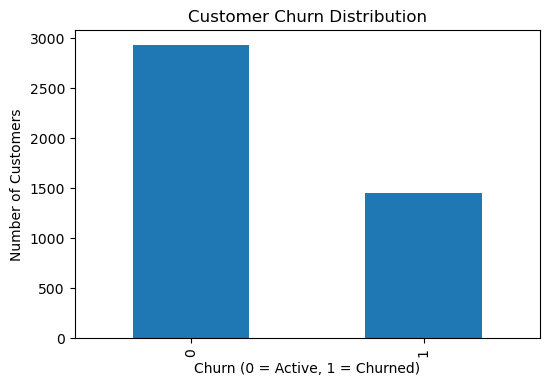

In [52]:
import matplotlib.pyplot as plt

churn_counts = customer_last_purchase['Churn'].value_counts()

plt.figure(figsize=(6,4))

churn_counts.plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

## B2. Feature Engineering

Feature engineering is the process of creating meaningful variables that help machine learning models better understand patterns in the data.

In this project, a **customer-level feature table** is created. The features include variables derived from the **RFM analysis** as well as additional engineered variables that capture customer purchasing behaviour.

The feature table will later be used as the input dataset for building predictive models to identify customers who are likely to churn.

### Using RFM Features

The RFM table already provides three important behavioural indicators:

- **Recency:** Number of days since the customer's last purchase
- **Frequency:** Number of unique orders placed
- **Monetary:** Total revenue generated by the customer

These variables are strong predictors of customer churn because they capture purchase activity and customer value.

In [54]:
# Start feature table from RFM data
features = rfm[['Recency','Frequency','Monetary']].copy()

features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-64.68
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


### Feature 1: Average Order Value

Average Order Value (AOV) measures how much a customer spends per order.

Customers with higher AOV typically represent higher-value customers and may have stronger engagement with the company. Lower AOV customers may be more price-sensitive and more likely to churn.

In [55]:
# Calculate Average Order Value
aov = df.groupby('Customer ID').agg({
    'Revenue':'sum',
    'Invoice':'nunique'
})

aov['AverageOrderValue'] = aov['Revenue'] / aov['Invoice']

features['AverageOrderValue'] = aov['AverageOrderValue']

features.head()

,Recency,Frequency,Monetary,AverageOrderValue
Customer ID,,,,
12346.0,67,15,-64.68,-4.3120
12347.0,3,2,1323.32,661.6600
12348.0,74,1,222.16,222.1600
12349.0,43,4,2646.99,661.7475
12351.0,11,1,300.93,300.9300


### Feature 2: Number of Unique Products Purchased

This feature measures the diversity of products purchased by a customer.

Customers who purchase a wide range of products are generally more engaged with the brand and less likely to churn compared to customers who repeatedly purchase only one product.

In [56]:
# Unique products purchased by each customer
unique_products = df.groupby('Customer ID')['StockCode'].nunique()

features['UniqueProducts'] = unique_products

features.head()

,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
Customer ID,,,,,
12346.0,67,15,-64.68,-4.3120,29
12347.0,3,2,1323.32,661.6600,70
12348.0,74,1,222.16,222.1600,20
12349.0,43,4,2646.99,661.7475,92
12351.0,11,1,300.93,300.9300,21


### Feature 3: Average Days Between Purchases

This feature measures the average time gap between purchases for each customer.

Customers who purchase frequently (smaller gaps between purchases) are typically more loyal, while customers with longer gaps between purchases may be more likely to churn.

In [57]:
# Sort transactions by customer and date
df_sorted = df.sort_values(['Customer ID','InvoiceDate'])

# Calculate time difference between purchases
df_sorted['PreviousPurchase'] = df_sorted.groupby('Customer ID')['InvoiceDate'].shift(1)

df_sorted['DaysBetweenPurchases'] = (df_sorted['InvoiceDate'] - df_sorted['PreviousPurchase']).dt.days

# Calculate average days between purchases
avg_days = df_sorted.groupby('Customer ID')['DaysBetweenPurchases'].mean()

features['AvgDaysBetweenPurchases'] = avg_days

features.head()

,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,AvgDaysBetweenPurchases
Customer ID,,,,,,
12346.0,67,15,-64.68,-4.3120,29,6.400000
12347.0,3,2,1323.32,661.6600,70,0.528571
12348.0,74,1,222.16,222.1600,20,0.000000
12349.0,43,4,2646.99,661.7475,92,3.075472
12351.0,11,1,300.93,300.9300,21,0.000000


### Feature 4: Return Rate

Negative quantities in the dataset typically represent product returns.

Return rate measures the proportion of returned transactions relative to total transactions for each customer.

Customers with higher return rates may be less satisfied with products and therefore more likely to churn.

In [58]:
# Identify returns
df['IsReturn'] = df['Quantity'] < 0

return_rate = df.groupby('Customer ID')['IsReturn'].mean()

features['ReturnRate'] = return_rate

features.head()

,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,AvgDaysBetweenPurchases,ReturnRate
Customer ID,,,,,,,
12346.0,67,15,-64.68,-4.3120,29,6.400000,0.282609
12347.0,3,2,1323.32,661.6600,70,0.528571,0.000000
12348.0,74,1,222.16,222.1600,20,0.000000,0.000000
12349.0,43,4,2646.99,661.7475,92,3.075472,0.046729
12351.0,11,1,300.93,300.9300,21,0.000000,0.000000


### Merge Churn Target Variable

The churn target variable created earlier is merged with the feature table so that the dataset can be used for training predictive models.

In [59]:
# Merge churn variable
features = features.merge(
    customer_last_purchase[['Customer ID','Churn']],
    left_index=True,
    right_on='Customer ID',
    how='left'
)

features.head()

,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,AvgDaysBetweenPurchases,ReturnRate,Customer ID,Churn
0,67,15,-64.68,-4.3120,29,6.400000,0.282609,12346.0,0
1,3,2,1323.32,661.6600,70,0.528571,0.000000,12347.0,0
2,74,1,222.16,222.1600,20,0.000000,0.000000,12348.0,0
3,43,4,2646.99,661.7475,92,3.075472,0.046729,12349.0,0
4,11,1,300.93,300.9300,21,0.000000,0.000000,12351.0,0


### Final Customer-Level Feature Table

The final feature table contains behavioural metrics for each customer along with the churn label.

Features included:

- Recency
- Frequency
- Monetary
- Average Order Value
- Unique Products Purchased
- Average Days Between Purchases
- Return Rate
- Churn (Target Variable)

This dataset will be used in the next step to train machine learning models for churn prediction.

In [60]:
# Check final dataset
features.info()

features.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Recency                  4383 non-null   int64  
 1   Frequency                4383 non-null   int64  
 2   Monetary                 4383 non-null   float64
 3   AverageOrderValue        4383 non-null   float64
 4   UniqueProducts           4383 non-null   int64  
 5   AvgDaysBetweenPurchases  4249 non-null   float64
 6   ReturnRate               4383 non-null   float64
 7   Customer ID              4383 non-null   float64
 8   Churn                    4383 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 308.3 KB


,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,AvgDaysBetweenPurchases,ReturnRate,Customer ID,Churn
0,67,15,-64.68,-4.3120,29,6.400000,0.282609,12346.0,0
1,3,2,1323.32,661.6600,70,0.528571,0.000000,12347.0,0
2,74,1,222.16,222.1600,20,0.000000,0.000000,12348.0,0
3,43,4,2646.99,661.7475,92,3.075472,0.046729,12349.0,0
4,11,1,300.93,300.9300,21,0.000000,0.000000,12351.0,0


## B3. Model Building and Evaluation

In this section, machine learning models are developed to predict customer churn.

Two classification algorithms are used:

- Logistic Regression
- Random Forest

The dataset is split into training and testing sets using an **80/20 split**.  
The models are evaluated using multiple performance metrics to ensure reliable prediction performance.

Evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Confusion matrices are also used to visualize the classification performance of each model.

### Prepare Features and Target Variable

Before training the models, the dataset is separated into:

- **Feature variables (X)** — independent variables used to predict churn
- **Target variable (y)** — churn label (0 = active, 1 = churned)

In [65]:
# Separate features and target variable
X = features.drop(columns=['Customer ID','Churn'])
y = features['Churn']

X.head()

,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,AvgDaysBetweenPurchases,ReturnRate
0,67,15,-64.68,-4.3120,29,6.400000,0.282609
1,3,2,1323.32,661.6600,70,0.528571,0.000000
2,74,1,222.16,222.1600,20,0.000000,0.000000
3,43,4,2646.99,661.7475,92,3.075472,0.046729
4,11,1,300.93,300.9300,21,0.000000,0.000000


### Train-Test Split

The dataset is split into training and testing sets.

- **80% Training Data** — used to train the model
- **20% Testing Data** — used to evaluate model performance

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

### Feature Scaling

Feature scaling is applied because Logistic Regression performs better when numerical features are standardized.

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Fill Missing Values

Use mean imputation.

In [66]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

### Logistic Regression Model

Logistic Regression is a statistical classification model used to predict binary outcomes.  
In this project, it predicts whether a customer will churn or remain active.

In [67]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

### Random Forest Model

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions.

It often performs well for customer behaviour prediction because it captures complex relationships in the data.

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]

### Model Evaluation Metrics

To evaluate the performance of both models, the following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Using multiple metrics provides a more complete understanding of model performance, especially when predicting churn.

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    return accuracy, precision, recall, f1, roc_auc

In [70]:
log_metrics = evaluate_model(y_test, log_pred, log_prob)

print("Logistic Regression Performance")
print("Accuracy:", log_metrics[0])
print("Precision:", log_metrics[1])
print("Recall:", log_metrics[2])
print("F1 Score:", log_metrics[3])
print("ROC-AUC:", log_metrics[4])

Logistic Regression Performance
Accuracy: 0.9965792474344356
Precision: 1.0
Recall: 0.9892857142857143
F1 Score: 0.9946140035906643
ROC-AUC: 1.0


In [74]:
rf_metrics = evaluate_model(y_test, rf_pred, rf_prob)

print("Random Forest Performance")
print("Accuracy:", rf_metrics[0])
print("Precision:", rf_metrics[1])
print("Recall:", rf_metrics[2])
print("F1 Score:", rf_metrics[3])
print("ROC-AUC:", rf_metrics[4])

Random Forest Performance
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the model.

It includes:

- True Positives
- True Negatives
- False Positives
- False Negatives

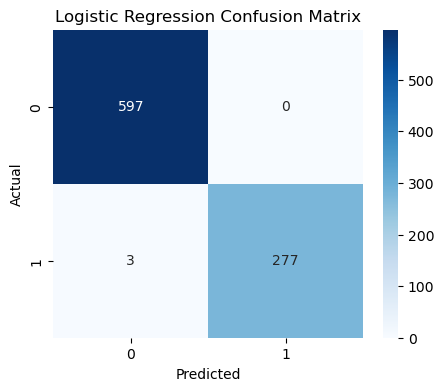

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

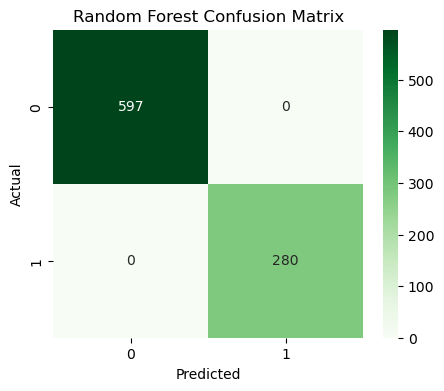

In [76]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## B4. Feature Importance and Business Interpretation

In this section, we analyze which features are most influential in predicting customer churn using the Random Forest model.

Random Forest models provide **feature importance scores**, which indicate how much each variable contributes to the prediction.

By identifying the most important predictors of churn, the business can better understand the factors that influence customer retention and design targeted strategies to reduce churn.

### Extract Feature Importance

The Random Forest model assigns an importance score to each feature based on how much it contributes to reducing prediction error.

Higher importance values indicate that the feature plays a stronger role in predicting customer churn.

In [86]:
# Extract feature importance
importances = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head()

,Feature,Importance
0,Recency,0.850493
2,Monetary,0.043325
1,Frequency,0.037196
4,UniqueProducts,0.032619
5,AvgDaysBetweenPurchases,0.020809


### Top 8 Most Important Features

The top features with the highest importance scores are selected for visualization. These features have the strongest influence on the model’s churn predictions.

In [87]:
top_features = importance_df.head(8)

top_features

,Feature,Importance
0,Recency,0.850493
2,Monetary,0.043325
1,Frequency,0.037196
4,UniqueProducts,0.032619
5,AvgDaysBetweenPurchases,0.020809
3,AverageOrderValue,0.010621
6,ReturnRate,0.004937


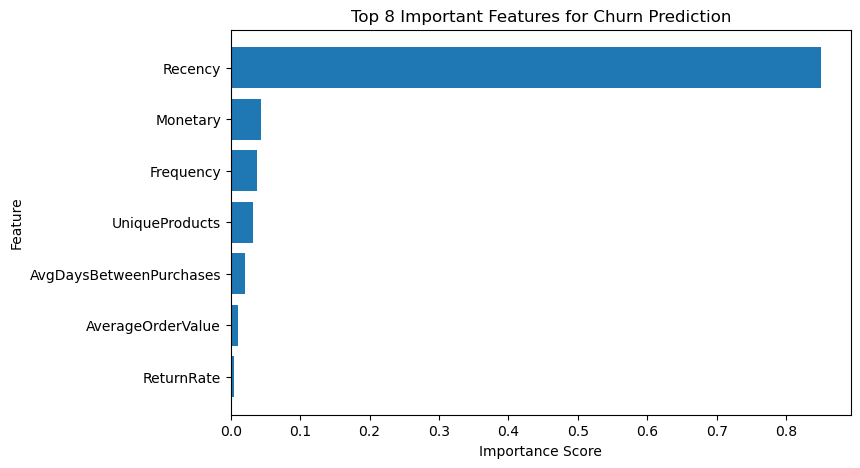

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.title("Top 8 Important Features for Churn Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()